In [ ]:
# ================================================================
# 🍅 TOMATO — FINAL MODEL TRAINING PRE-CHECK
# READ-ONLY AUDIT
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np

# ------------------------------------------------
# PROJECT PATH
# ------------------------------------------------
BASE = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"

PREPROCESS = os.path.join(BASE, "3rd Preprocessing")
TRAINING   = os.path.join(BASE, "4th Model_Training")
MODEL      = os.path.join(BASE, "6th Trained_Model")

NPZ_PATH = os.path.join(PREPROCESS, "tomato_processed_data.npz")


# ------------------------------------------------
# HELPER
# ------------------------------------------------
def size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)


def check_folder(folder):
    print("\n" + "=" * 70)
    print(f"📁 {os.path.basename(folder)}")
    print("=" * 70)

    if not os.path.exists(folder):
        print("❌ FOLDER NOT FOUND")
        return

    files = []

    for root, dirs, filenames in os.walk(folder):
        for f in filenames:
            files.append(os.path.join(root, f))

    if not files:
        print("⚠️ Folder is empty")
        return

    print(f"Total files: {len(files)}")

    for path in files:
        rel = os.path.relpath(path, folder)
        print(f"\n📄 {rel}")
        print(f"   Size: {size_mb(path):.2f} MB")


# ================================================================
# 1️⃣ PREPROCESSING FOLDER
# ================================================================

check_folder(PREPROCESS)


# ================================================================
# 2️⃣ TOMATO NPZ DEEP CHECK
# ================================================================

print("\n" + "=" * 70)
print("🍅 TOMATO NPZ DATASET CHECK")
print("=" * 70)

if not os.path.exists(NPZ_PATH):

    print("❌ tomato_processed_data.npz NOT FOUND")

else:

    print("✅ tomato_processed_data.npz FOUND")
    print(f"Size: {size_mb(NPZ_PATH):.2f} MB")

    try:

        data = np.load(NPZ_PATH, allow_pickle=True)

        print("\nStored arrays:")
        print(data.files)

        for key in data.files:

            arr = data[key]

            print(f"\n➡️ {key}")
            print(f"   Shape : {arr.shape}")
            print(f"   Dtype : {arr.dtype}")

        # --------------------------------------------
        # EXPECTED DATA CHECK
        # --------------------------------------------

        required = ["X", "y", "class_names", "sources"]

        print("\nRequired arrays:")

        for key in required:

            if key in data.files:
                print(f"   ✅ {key}")
            else:
                print(f"   ❌ {key} MISSING")

        # --------------------------------------------
        # CLASS CHECK
        # --------------------------------------------

        if "y" in data.files and "class_names" in data.files:

            y = data["y"]
            class_names = data["class_names"]

            print("\nClass distribution:")

            for i, name in enumerate(class_names):
                print(f"   {i} → {name}: {np.sum(y == i)}")

        # --------------------------------------------
        # SOURCE CHECK
        # --------------------------------------------

        if "sources" in data.files:

            sources = data["sources"]

            print("\nSource distribution:")

            unique, counts = np.unique(sources, return_counts=True)

            for source, count in zip(unique, counts):
                print(f"   {source}: {count}")

        data.close()

        print("\n✅ NPZ LOAD TEST PASSED")

    except Exception as e:

        print("\n❌ NPZ LOAD TEST FAILED")
        print("ERROR:", e)


# ================================================================
# 3️⃣ MODEL TRAINING FOLDER
# ================================================================

check_folder(TRAINING)


# ================================================================
# 4️⃣ CHECK JUPYTER NOTEBOOKS
# ================================================================

print("\n" + "=" * 70)
print("📓 MODEL TRAINING NOTEBOOK CHECK")
print("=" * 70)

if os.path.exists(TRAINING):

    notebooks = [
        f for f in os.listdir(TRAINING)
        if f.lower().endswith(".ipynb")
    ]

    if not notebooks:

        print("⚠️ No .ipynb file found")

    else:

        for notebook in notebooks:

            path = os.path.join(TRAINING, notebook)

            print(f"\n📓 {notebook}")
            print(f"Size: {size_mb(path):.2f} MB")

            try:

                with open(path, "r", encoding="utf-8") as f:
                    nb = json.load(f)

                cells = nb.get("cells", [])

                code_cells = [
                    c for c in cells
                    if c.get("cell_type") == "code"
                ]

                markdown_cells = [
                    c for c in cells
                    if c.get("cell_type") == "markdown"
                ]

                code_text = "\n".join(
                    "".join(c.get("source", []))
                    for c in code_cells
                )

                print(f"Code cells     : {len(code_cells)}")
                print(f"Markdown cells : {len(markdown_cells)}")
                print(f"Code available : {'YES' if code_text.strip() else 'NO'}")

                # Important keywords
                checks = {
                    "NPZ loading": "np.load",
                    "train_test_split": "train_test_split",
                    "CNN": "Conv2D",
                    "model.fit": "model.fit",
                    "validation": "validation",
                }

                print("\nImportant components:")

                for name, keyword in checks.items():

                    if keyword.lower() in code_text.lower():
                        print(f"   ✅ {name}")
                    else:
                        print(f"   ⚠️ {name} not found")

            except Exception as e:

                print(f"❌ Notebook reading failed: {e}")


# ================================================================
# 5️⃣ TRAINED MODEL FOLDER
# ================================================================

check_folder(MODEL)


# ================================================================
# 6️⃣ FINAL STATUS
# ================================================================

print("\n" + "=" * 70)
print("🏁 TOMATO MODEL TRAINING PRE-CHECK")
print("=" * 70)

print(f"NPZ dataset       : {'✅ READY' if os.path.exists(NPZ_PATH) else '❌ MISSING'}")
print(f"Training folder   : {'✅ EXISTS' if os.path.exists(TRAINING) else '❌ MISSING'}")
print(f"Trained model dir : {'✅ EXISTS' if os.path.exists(MODEL) else '❌ MISSING'}")

print("\n⚠️ READ-ONLY AUDIT COMPLETE")
print("❌ Nothing was deleted")
print("❌ Nothing was moved")
print("❌ Nothing was modified")

print("\nNEXT:")
print("➡️ Send me this output.")
print("➡️ We will check whether Tomato CNN training is completely ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📁 3rd Preprocessing
Total files: 6

📄 lab_potatod_preprocessing.ipynb
   Size: 0.02 MB

📄 lab_potatod_processed_potato_data.npz
   Size: 1235.74 MB

📄 potato_processed_data.npz
   Size: 743.45 MB

📄 Potato_Preprocessing.ipynb
   Size: 0.02 MB

📄 tomato_processed_data.npz
   Size: 152.01 MB

📄 Tomato_Preprocessing.ipynb
   Size: 0.08 MB

🍅 TOMATO NPZ DATASET CHECK
✅ tomato_processed_data.npz FOUND
Size: 152.01 MB

Stored arrays:
['X', 'y', 'class_names', 'source']

➡️ X
   Shape : (1800, 224, 224, 3)
   Dtype : uint8

➡️ y
   Shape : (1800,)
   Dtype : int64

➡️ class_names
   Shape : (3,)
   Dtype : <U12

➡️ source
   Shape : (1800,)
   Dtype : <U21

Required arrays:
   ✅ X
   ✅ y
   ✅ class_names
   ❌ sources MISSING

Class distribution:
   0 → Healthy: 600
   1 → Early_Blight: 600
   2 → Late_Blight: 600

✅ NPZ LOAD TEST PASSED

📁 4th Model_Training
Total 

In [ ]:
# ================================================================
# 🍅 TOMATO CNN NOTEBOOK — FINAL CODE INSPECTION
# READ-ONLY
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json

path = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/4th Model_Training/tomato_CNN_training.ipynb"

print("=" * 70)
print("🍅 TOMATO CNN TRAINING NOTEBOOK")
print("=" * 70)

if not os.path.exists(path):

    print("❌ Notebook NOT FOUND")

else:

    print("✅ Notebook found")
    print(f"Size: {os.path.getsize(path)/(1024*1024):.2f} MB")

    with open(path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    cells = nb.get("cells", [])

    print(f"\nTotal cells: {len(cells)}")

    for i, cell in enumerate(cells, 1):

        print("\n" + "-" * 70)
        print(f"CELL {i} — {cell.get('cell_type', 'unknown').upper()}")
        print("-" * 70)

        source = "".join(cell.get("source", []))

        print(source)

print("\n" + "=" * 70)
print("🏁 INSPECTION COMPLETE")
print("=" * 70)
print("❌ No file modified")
print("❌ No training started")
print("=" * 70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🍅 TOMATO CNN TRAINING NOTEBOOK
✅ Notebook found
Size: 0.35 MB

Total cells: 5

----------------------------------------------------------------------
CELL 1 — CODE
----------------------------------------------------------------------
# ================================================================
# 🍅 TOMATO — FINAL MODEL TRAINING PRE-CHECK
# READ-ONLY AUDIT
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np

# ------------------------------------------------
# PROJECT PATH
# ------------------------------------------------
BASE = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"

PREPROCESS = os.path.join(BASE, "3rd Preprocessing")
TRAINING   = os.path.join(BASE, "4th Model_Training")
MODEL      = os.path.join(BASE, "6th

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🧹 CLEANING OLD TOMATO MODEL
ℹ️ Not found:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/tomato_cnn_best.keras
🗑️ Deleted:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/4th Model_Training/tomato_CNN_training_history.npz
🗑️ Deleted:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/4th Model_Training/tomato_CNN_training_log.csv
🗑️ Deleted:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/4th Model_Training/tomato_CNN_training_summary.json

✅ Old Tomato training artifacts cleaned.
✅ Tomato NPZ dataset was NOT deleted.

🖥️ SYSTEM CHECK
TensorFlow version : 2.20.0
GPU available      : NO
⚠️ CPU training will be used.

📥 LOADING TOMATO DATASET
Dataset:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/3rd Preprocessing/tomato_processed_data.npz
Dataset size: 152.01

Model: "Tomato_MobileNetV2_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tomato_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


⚙️ PREPARING CALLBACKS

🚀 STARTING FINAL TOMATO CNN TRAINING
Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6149 - loss: 0.9049
Epoch 1: val_accuracy improved from None to 0.87037, saving model to /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/tomato_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/tomato_cnn_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.7381 - loss: 0.6050 - val_accuracy: 0.8704 - val_loss: 0.2830 - learning_rate: 0.0010
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8904 - loss: 0.3085
Epoch 2: val_accuracy improved from 0.87037 to 0.89630, saving model to /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/tomato_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/tomato_cnn_best.keras
40

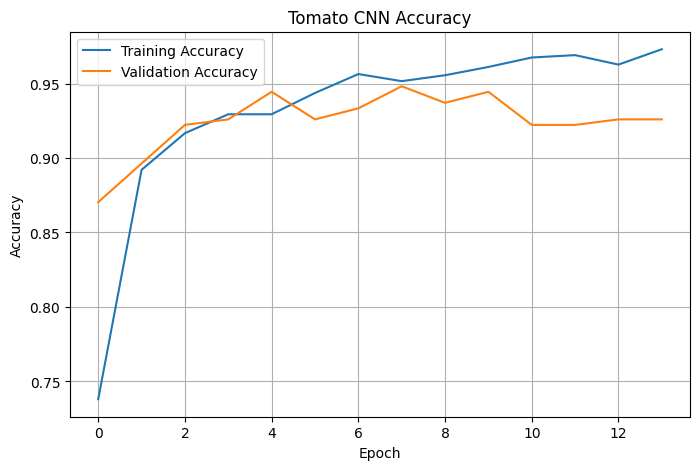

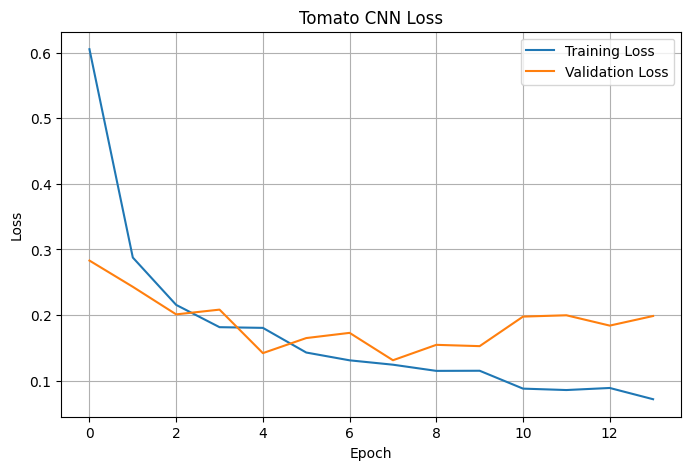


🏁 TOMATO CNN — FINAL VERIFICATION
✅ Tomato NPZ verified
✅ 1,800 images verified
✅ 224 × 224 × 3 verified
✅ 3 classes verified
✅ Balanced split verified
✅ Duplicate-safe split verified
✅ CNN model trained
✅ Best model saved
✅ Best model reloaded
✅ Test evaluation completed
✅ Prediction test completed
✅ Training history saved
✅ Training log saved
✅ Training summary saved

🍅 TOMATO CNN — FINAL MODEL READY

MODEL:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/tomato_cnn_best.keras

TEST ACCURACY:
94.81%

BEST VALIDATION ACCURACY:
94.81%

NEXT:
➡️ 5th Model_Evaluation


In [ ]:
# ================================================================
# 🍅 TOMATO CNN — FINAL MASTER TRAINING
# Plant Disease Detection — Computer Vision
# ================================================================

# ================================================================
# 0. MOUNT DRIVE
# ================================================================

from google.colab import drive
drive.mount("/content/drive")

# ================================================================
# 1. IMPORTS
# ================================================================

import os
import json
import csv
import random
import hashlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split

# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ================================================================
# 3. PROJECT PATHS
# ================================================================

BASE = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"

PREPROCESS_ROOT = os.path.join(
    BASE,
    "3rd Preprocessing"
)

TRAINING_ROOT = os.path.join(
    BASE,
    "4th Model_Training"
)

MODEL_ROOT = os.path.join(
    BASE,
    "6th Trained_Model"
)

NPZ_PATH = os.path.join(
    PREPROCESS_ROOT,
    "tomato_processed_data.npz"
)

MODEL_PATH = os.path.join(
    MODEL_ROOT,
    "tomato_cnn_best.keras"
)

HISTORY_PATH = os.path.join(
    TRAINING_ROOT,
    "tomato_CNN_training_history.npz"
)

LOG_PATH = os.path.join(
    TRAINING_ROOT,
    "tomato_CNN_training_log.csv"
)

SUMMARY_PATH = os.path.join(
    TRAINING_ROOT,
    "tomato_CNN_training_summary.json"
)

# ================================================================
# 4. CREATE REQUIRED FOLDERS
# ================================================================

os.makedirs(PREPROCESS_ROOT, exist_ok=True)
os.makedirs(TRAINING_ROOT, exist_ok=True)
os.makedirs(MODEL_ROOT, exist_ok=True)

# ================================================================
# 5. DELETE ONLY OLD TOMATO TRAINING ARTIFACTS
# ================================================================

print("=" * 70)
print("🧹 CLEANING OLD TOMATO MODEL")
print("=" * 70)

old_files = [
    MODEL_PATH,
    HISTORY_PATH,
    LOG_PATH,
    SUMMARY_PATH
]

for path in old_files:

    if os.path.exists(path):

        os.remove(path)

        print("🗑️ Deleted:")
        print(path)

    else:

        print("ℹ️ Not found:")
        print(path)

print("\n✅ Old Tomato training artifacts cleaned.")
print("✅ Tomato NPZ dataset was NOT deleted.")

# ================================================================
# 6. SYSTEM CHECK
# ================================================================

print("\n" + "=" * 70)
print("🖥️ SYSTEM CHECK")
print("=" * 70)

print("TensorFlow version :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:

    print("GPU available      : YES")
    print("GPU devices        :", gpus)

else:

    print("GPU available      : NO")
    print("⚠️ CPU training will be used.")

# ================================================================
# 7. DATASET CHECK
# ================================================================

print("\n" + "=" * 70)
print("📥 LOADING TOMATO DATASET")
print("=" * 70)

if not os.path.exists(NPZ_PATH):

    raise FileNotFoundError(
        "\n❌ Tomato dataset not found:\n"
        + NPZ_PATH
    )

print("Dataset:")
print(NPZ_PATH)

print(
    "Dataset size:",
    round(
        os.path.getsize(NPZ_PATH) / (1024 ** 2),
        2
    ),
    "MB"
)

data = np.load(
    NPZ_PATH,
    allow_pickle=False
)

print("\nStored arrays:")
print(data.files)

# ================================================================
# 8. REQUIRED ARRAYS
# ================================================================

required_arrays = [
    "X",
    "y",
    "class_names",
    "source"
]

for key in required_arrays:

    if key not in data.files:

        raise KeyError(
            f"❌ Required array missing: {key}"
        )

    print(f"   ✅ {key}")

# ================================================================
# 9. LOAD DATA
# ================================================================

X = data["X"]
y = data["y"]
class_names = data["class_names"]
sources = data["source"]

data.close()

# ================================================================
# 10. DATASET VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("🔎 DATASET VALIDATION")
print("=" * 70)

print("X shape      :", X.shape)
print("X dtype      :", X.dtype)

print("y shape      :", y.shape)
print("y dtype      :", y.dtype)

print("class_names  :", class_names)

print("source shape :", sources.shape)
print("source dtype :", sources.dtype)

assert X.shape == (1800, 224, 224, 3)
assert len(y) == 1800
assert len(sources) == 1800
assert len(class_names) == 3

assert X.dtype == np.uint8

print("\n✅ Dataset dimensions verified.")

# ================================================================
# 11. CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("📊 CLASS DISTRIBUTION")
print("=" * 70)

for i, name in enumerate(class_names):

    count = np.sum(y == i)

    print(
        f"{i} → {name:15} : {count}"
    )

    assert count == 600

print("\n✅ Classes perfectly balanced.")

# ================================================================
# 12. SOURCE DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("🌱 SOURCE DISTRIBUTION")
print("=" * 70)

unique_sources, source_counts = np.unique(
    sources,
    return_counts=True
)

for source_name, count in zip(
    unique_sources,
    source_counts
):

    print(
        f"{source_name:25} : {count}"
    )

# ================================================================
# 13. EXACT DUPLICATE CHECK
# ================================================================

print("\n" + "=" * 70)
print("🔍 EXACT DUPLICATE CHECK")
print("=" * 70)

hash_to_indices = {}

for i, image in enumerate(X):

    image_hash = hashlib.sha256(
        image.tobytes()
    ).hexdigest()

    if image_hash not in hash_to_indices:

        hash_to_indices[image_hash] = []

    hash_to_indices[image_hash].append(i)

duplicate_groups = [
    indices
    for indices in hash_to_indices.values()
    if len(indices) > 1
]

print("Total images          :", len(X))
print("Unique image contents :", len(hash_to_indices))
print("Duplicate groups      :", len(duplicate_groups))

if duplicate_groups:

    for group in duplicate_groups:

        print(
            "Duplicate group:",
            group
        )

else:

    print("No exact duplicates found.")

# ================================================================
# 14. BUILD DUPLICATE-SAFE GROUPS
# ================================================================

print("\n" + "=" * 70)
print("🔐 BUILDING DUPLICATE-SAFE GROUPS")
print("=" * 70)

groups = []

for image_hash, indices in hash_to_indices.items():

    first_index = indices[0]

    groups.append({
        "hash": image_hash,
        "indices": indices,
        "label": int(y[first_index]),
        "source": str(sources[first_index])
    })

print(
    "Total image groups:",
    len(groups)
)

# ================================================================
# 15. SOURCE + CLASS STRATIFIED SPLIT
# ================================================================
#
# Every class/source combination is balanced.
#
# Each combination contains 300 images.
#
# Target:
# Train      = 210
# Validation = 45
# Test       = 45
#
# Total:
# Train      = 1260
# Validation = 270
# Test       = 270
#
# Duplicate groups remain together.
# ================================================================

print("\n" + "=" * 70)
print("📊 CREATING BALANCED TRAIN / VAL / TEST SPLIT")
print("=" * 70)

rng = np.random.default_rng(SEED)

train_idx = []
val_idx = []
test_idx = []

# ------------------------------------------------
# Process every CLASS + SOURCE combination
# ------------------------------------------------

for class_id in range(len(class_names)):

    for source_name in unique_sources:

        matching_groups = [
            g
            for g in groups
            if g["label"] == class_id
            and g["source"] == str(source_name)
        ]

        if not matching_groups:

            raise ValueError(
                f"No data found for "
                f"{class_names[class_id]} / {source_name}"
            )

        rng.shuffle(matching_groups)

        # ------------------------------------------------
        # Target counts
        # ------------------------------------------------

        target_train = 210
        target_val = 45
        target_test = 45

        selected_train = []
        selected_val = []
        selected_test = []

        train_count = 0
        val_count = 0
        test_count = 0

        # ------------------------------------------------
        # Fill TRAIN
        # ------------------------------------------------

        remaining = matching_groups.copy()

        while remaining:

            g = remaining[0]
            size = len(g["indices"])

            if train_count + size <= target_train:

                selected_train.append(g)
                train_count += size
                remaining.pop(0)

            else:

                break

        # ------------------------------------------------
        # Fill VALIDATION
        # ------------------------------------------------

        while remaining:

            g = remaining[0]
            size = len(g["indices"])

            if val_count + size <= target_val:

                selected_val.append(g)
                val_count += size
                remaining.pop(0)

            else:

                break

        # ------------------------------------------------
        # Fill TEST
        # ------------------------------------------------

        for g in remaining:

            selected_test.append(g)
            test_count += len(g["indices"])

        # ------------------------------------------------
        # Validate exact totals
        # ------------------------------------------------

        if (
            train_count != target_train
            or val_count != target_val
            or test_count != target_test
        ):

            raise RuntimeError(
                "\n❌ Unable to create exact balanced split.\n"
                f"Class: {class_names[class_id]}\n"
                f"Source: {source_name}\n"
                f"Train: {train_count}\n"
                f"Val: {val_count}\n"
                f"Test: {test_count}"
            )

        for g in selected_train:
            train_idx.extend(g["indices"])

        for g in selected_val:
            val_idx.extend(g["indices"])

        for g in selected_test:
            test_idx.extend(g["indices"])

# ------------------------------------------------
# Convert to arrays
# ------------------------------------------------

train_idx = np.array(
    sorted(train_idx),
    dtype=np.int32
)

val_idx = np.array(
    sorted(val_idx),
    dtype=np.int32
)

test_idx = np.array(
    sorted(test_idx),
    dtype=np.int32
)

# ================================================================
# 16. SPLIT VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("🔐 VERIFYING SPLIT")
print("=" * 70)

print("Train      :", len(train_idx))
print("Validation :", len(val_idx))
print("Test       :", len(test_idx))

assert len(train_idx) == 1260
assert len(val_idx) == 270
assert len(test_idx) == 270

assert len(
    set(train_idx) &
    set(val_idx)
) == 0

assert len(
    set(train_idx) &
    set(test_idx)
) == 0

assert len(
    set(val_idx) &
    set(test_idx)
) == 0

all_indices = np.concatenate(
    [
        train_idx,
        val_idx,
        test_idx
    ]
)

assert len(np.unique(all_indices)) == 1800

print("\n✅ No split leakage.")
print("✅ All 1800 images accounted for.")

# ================================================================
# 17. CREATE DATASETS
# ================================================================

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

# ================================================================
# 18. VERIFY CLASS BALANCE
# ================================================================

print("\n" + "=" * 70)
print("📊 FINAL SPLIT CLASS CHECK")
print("=" * 70)

for i, name in enumerate(class_names):

    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)

    print(f"\n{name}")

    print("Train      :", train_count)
    print("Validation :", val_count)
    print("Test       :", test_count)

    assert train_count == 420
    assert val_count == 90
    assert test_count == 90

print("\n✅ Perfect class balance.")

# ================================================================
# 19. CONVERT DATA TYPE
# ================================================================

X_train = X_train.astype(
    np.float32
)

X_val = X_val.astype(
    np.float32
)

X_test = X_test.astype(
    np.float32
)

print("\nPixel range:")
print("Minimum :", X_train.min())
print("Maximum :", X_train.max())

# ================================================================
# 20. BUILD TF.DATA PIPELINES
# ================================================================

BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

train_ds = (
    train_ds
    .shuffle(
        buffer_size=len(X_train),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("\n✅ TensorFlow datasets ready.")

# ================================================================
# 21. DATA AUGMENTATION
# ================================================================

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.08
    ),

    layers.RandomZoom(
        0.10
    ),

    layers.RandomContrast(
        0.10
    )

], name="tomato_augmentation")

# ================================================================
# 22. BUILD MOBILE NET V2 TRANSFER LEARNING MODEL
# ================================================================

print("\n" + "=" * 70)
print("🧠 BUILDING FINAL TOMATO CNN")
print("=" * 70)

base_model = tf.keras.applications.MobileNetV2(

    input_shape=(224, 224, 3),

    include_top=False,

    weights="imagenet"
)

# Freeze pretrained CNN
base_model.trainable = False

inputs = layers.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(
    x
)

# Important: inference mode for frozen BN layers
x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(
    0.30
)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(
    0.20
)(x)

outputs = layers.Dense(
    3,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="Tomato_MobileNetV2_CNN"
)

# ================================================================
# 23. COMPILE MODEL
# ================================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

model.summary()

# ================================================================
# 24. CALLBACKS
# ================================================================

print("\n" + "=" * 70)
print("⚙️ PREPARING CALLBACKS")
print("=" * 70)

checkpoint = callbacks.ModelCheckpoint(

    MODEL_PATH,

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    verbose=1
)

early_stop = callbacks.EarlyStopping(

    monitor="val_accuracy",

    mode="max",

    patience=6,

    restore_best_weights=True,

    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=3,

    min_lr=1e-6,

    verbose=1
)

csv_logger = callbacks.CSVLogger(
    LOG_PATH,
    append=False
)

# ================================================================
# 25. FINAL TRAINING
# ================================================================

print("\n" + "=" * 70)
print("🚀 STARTING FINAL TOMATO CNN TRAINING")
print("=" * 70)

INITIAL_EPOCHS = 15

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=INITIAL_EPOCHS,

    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr,
        csv_logger
    ],

    verbose=1
)

print("\n" + "=" * 70)
print("🎉 FINAL TOMATO TRAINING FINISHED")
print("=" * 70)

print(
    "Epochs completed:",
    len(history.history["loss"])
)

# ================================================================
# 26. LOAD BEST MODEL
# ================================================================

print("\n" + "=" * 70)
print("🔄 LOADING BEST TOMATO MODEL")
print("=" * 70)

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        "❌ Best Tomato model was not saved."
    )

best_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("✅ Best model loaded.")

print(
    "Model size:",
    round(
        os.path.getsize(MODEL_PATH)
        / (1024 ** 2),
        2
    ),
    "MB"
)

# ================================================================
# 27. FINAL TEST EVALUATION
# ================================================================

print("\n" + "=" * 70)
print("🧪 FINAL TOMATO TEST")
print("=" * 70)

test_results = best_model.evaluate(
    test_ds,
    verbose=1,
    return_dict=True
)

test_loss = float(
    test_results["loss"]
)

test_accuracy = float(
    test_results["accuracy"]
)

print("\nTest Loss     :", round(test_loss, 4))

print(
    "Test Accuracy :",
    round(test_accuracy, 4)
)

print(
    "Test Accuracy :",
    round(test_accuracy * 100, 2),
    "%"
)

# ================================================================
# 28. PREDICTIONS
# ================================================================

print("\n" + "=" * 70)
print("🔮 PREDICTION CHECK")
print("=" * 70)

predictions = best_model.predict(
    X_test[:10],
    verbose=0
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

for i in range(10):

    actual = class_names[
        y_test[i]
    ]

    predicted = class_names[
        predicted_classes[i]
    ]

    confidence = (
        np.max(predictions[i]) * 100
    )

    print(
        f"Image {i+1:02d} | "
        f"Actual: {actual:15} | "
        f"Predicted: {predicted:15} | "
        f"Confidence: {confidence:.2f}%"
    )

# ================================================================
# 29. SAVE TRAINING HISTORY
# ================================================================

np.savez(

    HISTORY_PATH,

    accuracy=np.array(
        history.history["accuracy"]
    ),

    val_accuracy=np.array(
        history.history["val_accuracy"]
    ),

    loss=np.array(
        history.history["loss"]
    ),

    val_loss=np.array(
        history.history["val_loss"]
    )
)

print("\n✅ Training history saved.")

# ================================================================
# 30. SAVE SUMMARY
# ================================================================

best_val_accuracy = max(
    history.history["val_accuracy"]
)

best_train_accuracy = max(
    history.history["accuracy"]
)

summary = {

    "model": "MobileNetV2 Transfer Learning",

    "dataset": "tomato_processed_data.npz",

    "total_images": 1800,

    "image_shape": [
        224,
        224,
        3
    ],

    "classes": [
        str(x)
        for x in class_names
    ],

    "train_images": int(len(X_train)),

    "validation_images": int(len(X_val)),

    "test_images": int(len(X_test)),

    "best_training_accuracy": float(
        best_train_accuracy
    ),

    "best_validation_accuracy": float(
        best_val_accuracy
    ),

    "test_accuracy": float(
        test_accuracy
    ),

    "test_loss": float(
        test_loss
    ),

    "epochs_completed": int(
        len(history.history["loss"])
    ),

    "model_path": MODEL_PATH,

    "dataset_path": NPZ_PATH

}

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )

print("✅ Training summary saved.")

# ================================================================
# 31. TRAINING GRAPHS
# ================================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Tomato CNN Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()
plt.grid(True)
plt.show()


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Tomato CNN Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()
plt.grid(True)
plt.show()

# ================================================================
# 32. FINAL VERIFICATION
# ================================================================

print("\n" + "=" * 70)
print("🏁 TOMATO CNN — FINAL VERIFICATION")
print("=" * 70)

assert os.path.exists(
    NPZ_PATH
)

assert os.path.exists(
    MODEL_PATH
)

assert os.path.exists(
    HISTORY_PATH
)

assert os.path.exists(
    LOG_PATH
)

assert os.path.exists(
    SUMMARY_PATH
)

assert len(X_train) == 1260
assert len(X_val) == 270
assert len(X_test) == 270

assert predictions.shape == (
    10,
    3
)

print("✅ Tomato NPZ verified")
print("✅ 1,800 images verified")
print("✅ 224 × 224 × 3 verified")
print("✅ 3 classes verified")
print("✅ Balanced split verified")
print("✅ Duplicate-safe split verified")
print("✅ CNN model trained")
print("✅ Best model saved")
print("✅ Best model reloaded")
print("✅ Test evaluation completed")
print("✅ Prediction test completed")
print("✅ Training history saved")
print("✅ Training log saved")
print("✅ Training summary saved")

print("\n" + "=" * 70)
print("🍅 TOMATO CNN — FINAL MODEL READY")
print("=" * 70)

print("\nMODEL:")
print(MODEL_PATH)

print("\nTEST ACCURACY:")
print(
    f"{test_accuracy * 100:.2f}%"
)

print("\nBEST VALIDATION ACCURACY:")
print(
    f"{best_val_accuracy * 100:.2f}%"
)

print("\nNEXT:")
print("➡️ 5th Model_Evaluation")

In [ ]:
# ================================================================
# 🍅 TOMATO CNN — COMPLETE DRIVE STORAGE AUDIT
# READ-ONLY — NOTHING WILL BE DELETED
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
from datetime import datetime

# ------------------------------------------------
# ROOT PROJECT
# ------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"
)

print("=" * 80)
print("🍅 TOMATO CNN — COMPLETE STORAGE AUDIT")
print("=" * 80)

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project folder not found:\n{PROJECT_ROOT}"
    )

print(f"\n📁 Project root:")
print(PROJECT_ROOT)

# ------------------------------------------------
# 1. LIST ALL TOP-LEVEL FOLDERS
# ------------------------------------------------

print("\n" + "=" * 80)
print("📂 PROJECT FOLDERS")
print("=" * 80)

folders = sorted(
    [p for p in PROJECT_ROOT.iterdir() if p.is_dir()],
    key=lambda x: x.name.lower()
)

for i, folder in enumerate(folders, 1):
    print(f"{i:02d}. {folder.name}")

print(f"\nTotal folders: {len(folders)}")

# ------------------------------------------------
# 2. SCAN ALL FILES
# ------------------------------------------------

all_files = []

for path in PROJECT_ROOT.rglob("*"):
    if path.is_file():
        try:
            size_mb = path.stat().st_size / (1024 * 1024)
            modified = datetime.fromtimestamp(
                path.stat().st_mtime
            ).strftime("%Y-%m-%d %H:%M:%S")

            all_files.append({
                "path": path,
                "relative": path.relative_to(PROJECT_ROOT),
                "name": path.name,
                "extension": path.suffix.lower(),
                "size_mb": size_mb,
                "modified": modified
            })

        except Exception:
            pass

all_files.sort(
    key=lambda x: str(x["relative"]).lower()
)

print("\n" + "=" * 80)
print("📦 COMPLETE PROJECT FILE COUNT")
print("=" * 80)

print(f"Total files found: {len(all_files)}")

# ------------------------------------------------
# 3. TOMATO-RELATED FILES
# ------------------------------------------------

tomato_files = [
    f for f in all_files
    if "tomato" in f["name"].lower()
    or "tomato" in str(f["relative"]).lower()
]

print("\n" + "=" * 80)
print("🍅 ALL TOMATO-RELATED FILES")
print("=" * 80)

if not tomato_files:
    print("❌ No Tomato-related files found.")
else:

    for i, f in enumerate(tomato_files, 1):

        print(f"\n[{i}]")
        print(f"Path      : {f['relative']}")
        print(f"Extension : {f['extension'] or '[none]'}")
        print(f"Size      : {f['size_mb']:.2f} MB")
        print(f"Modified  : {f['modified']}")

    print(f"\nTotal Tomato-related files: {len(tomato_files)}")

# ------------------------------------------------
# 4. IMPORTANT MODEL FILES
# ------------------------------------------------

model_files = [
    f for f in all_files
    if f["extension"] in [
        ".keras",
        ".h5",
        ".hdf5"
    ]
]

print("\n" + "=" * 80)
print("🧠 ALL SAVED MODEL FILES")
print("=" * 80)

if not model_files:
    print("No saved model files found.")
else:

    for i, f in enumerate(model_files, 1):

        print(f"\n[{i}]")
        print(f"Path      : {f['relative']}")
        print(f"Size      : {f['size_mb']:.2f} MB")
        print(f"Modified  : {f['modified']}")

# ------------------------------------------------
# 5. TRAINING ARTIFACTS
# ------------------------------------------------

training_files = [
    f for f in all_files
    if any(keyword in f["name"].lower()
           for keyword in [
               "training",
               "history",
               "summary",
               "log"
           ])
]

print("\n" + "=" * 80)
print("📊 TRAINING ARTIFACTS")
print("=" * 80)

if not training_files:
    print("No training artifacts found.")
else:

    for i, f in enumerate(training_files, 1):

        print(f"\n[{i}]")
        print(f"Path      : {f['relative']}")
        print(f"Size      : {f['size_mb']:.2f} MB")
        print(f"Modified  : {f['modified']}")

# ------------------------------------------------
# 6. MODEL EVALUATION FILES
# ------------------------------------------------

evaluation_files = [
    f for f in all_files
    if any(keyword in f["name"].lower()
           for keyword in [
               "evaluation",
               "confusion",
               "classification",
               "prediction",
               "metric",
               "report"
           ])
]

print("\n" + "=" * 80)
print("🧪 EXISTING EVALUATION-RELATED FILES")
print("=" * 80)

if not evaluation_files:
    print("No evaluation-related files found.")
else:

    for i, f in enumerate(evaluation_files, 1):

        print(f"\n[{i}]")
        print(f"Path      : {f['relative']}")
        print(f"Size      : {f['size_mb']:.2f} MB")
        print(f"Modified  : {f['modified']}")

# ------------------------------------------------
# 7. SPECIFIC FINAL MODEL CHECK
# ------------------------------------------------

FINAL_MODEL = PROJECT_ROOT / \
    "6th Trained_Model" / \
    "tomato_cnn_best.keras"

print("\n" + "=" * 80)
print("🏆 FINAL TOMATO MODEL CHECK")
print("=" * 80)

if FINAL_MODEL.exists():

    size_mb = FINAL_MODEL.stat().st_size / (1024 * 1024)
    modified = datetime.fromtimestamp(
        FINAL_MODEL.stat().st_mtime
    ).strftime("%Y-%m-%d %H:%M:%S")

    print("✅ FINAL MODEL EXISTS")
    print(f"Path     : {FINAL_MODEL}")
    print(f"Size     : {size_mb:.2f} MB")
    print(f"Modified : {modified}")

else:

    print("❌ FINAL MODEL NOT FOUND")

# ------------------------------------------------
# 8. IMPORTANT DATASET CHECK
# ------------------------------------------------

DATASET = PROJECT_ROOT / \
    "3rd Preprocessing" / \
    "tomato_processed_data.npz"

print("\n" + "=" * 80)
print("📥 TOMATO DATASET CHECK")
print("=" * 80)

if DATASET.exists():

    size_mb = DATASET.stat().st_size / (1024 * 1024)

    print("✅ DATASET EXISTS")
    print(f"Path : {DATASET}")
    print(f"Size : {size_mb:.2f} MB")

else:

    print("❌ TOMATO DATASET NOT FOUND")

# ------------------------------------------------
# 9. FILE TYPE SUMMARY
# ------------------------------------------------

from collections import Counter

extensions = Counter(
    f["extension"] if f["extension"] else "[no extension]"
    for f in all_files
)

print("\n" + "=" * 80)
print("📑 FILE TYPE SUMMARY")
print("=" * 80)

for ext, count in sorted(extensions.items()):
    print(f"{ext:15s} : {count}")

# ------------------------------------------------
# FINAL MESSAGE
# ------------------------------------------------

print("\n" + "=" * 80)
print("🔒 AUDIT COMPLETE — NOTHING WAS DELETED")
print("=" * 80)

print("""
Next step:
Send me the COMPLETE OUTPUT of this cell.

I will classify every Tomato file into:

🟢 KEEP
🟡 REVIEW
🔴 DELETE

and then give you ONE safe cleanup code.

DO NOT DELETE ANYTHING MANUALLY YET.
""")

Streaming output truncated to the last 5000 lines.
Modified  : 2026-08-21 09:23:48

[2508]
Path      : 1st Raw_Data/Tomato/Internal_PlantVillage/Early_Blight/Tomato_Early_Blight_103.jpg
Extension : .jpg
Size      : 0.02 MB
Modified  : 2026-08-21 09:23:48

[2509]
Path      : 1st Raw_Data/Tomato/Internal_PlantVillage/Early_Blight/Tomato_Early_Blight_104.jpg
Extension : .jpg
Size      : 0.01 MB
Modified  : 2026-08-21 09:23:48

[2510]
Path      : 1st Raw_Data/Tomato/Internal_PlantVillage/Early_Blight/Tomato_Early_Blight_105.jpg
Extension : .jpg
Size      : 0.02 MB
Modified  : 2026-08-21 09:23:48

[2511]
Path      : 1st Raw_Data/Tomato/Internal_PlantVillage/Early_Blight/Tomato_Early_Blight_106.jpg
Extension : .jpg
Size      : 0.02 MB
Modified  : 2026-08-21 09:23:48

[2512]
Path      : 1st Raw_Data/Tomato/Internal_PlantVillage/Early_Blight/Tomato_Early_Blight_107.jpg
Extension : .jpg
Size      : 0.02 MB
Modified  : 2026-08-21 09:23:49

[2513]
Path      : 1st Raw_Data/Tomato/Internal_PlantVil

In [ ]:
# ================================================================
# 🍅 TOMATO CNN — FINAL DRIVE FILE AUDIT
# READ-ONLY — NOTHING WILL BE DELETED
# ================================================================

import os

PROJECT = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"

FOLDERS_TO_CHECK = {
    "3rd Preprocessing": os.path.join(
        PROJECT, "3rd Preprocessing"
    ),

    "4th Model_Training": os.path.join(
        PROJECT, "4th Model_Training"
    ),

    "5th Model_Evaluation": os.path.join(
        PROJECT, "5th Model_Evaluation"
    ),

    "6th Trained_Model": os.path.join(
        PROJECT, "6th Trained_Model"
    ),
}

print("=" * 80)
print("🍅 TOMATO CNN — FINAL DRIVE FILE AUDIT")
print("=" * 80)

for folder_name, folder_path in FOLDERS_TO_CHECK.items():

    print("\n" + "=" * 80)
    print(f"📁 {folder_name}")
    print("=" * 80)
    print("PATH:")
    print(folder_path)

    if not os.path.exists(folder_path):
        print("❌ FOLDER DOES NOT EXIST")
        continue

    files = sorted(os.listdir(folder_path))

    print(f"\nTotal items: {len(files)}")

    if len(files) == 0:
        print("📭 Folder is empty.")
        continue

    for i, item in enumerate(files, start=1):

        item_path = os.path.join(folder_path, item)

        if os.path.isfile(item_path):
            size_mb = os.path.getsize(item_path) / (1024 ** 2)

            print(
                f"{i:02d}. 📄 {item}"
                f" | {size_mb:.2f} MB"
            )

        elif os.path.isdir(item_path):
            print(
                f"{i:02d}. 📁 {item}"
            )


# ================================================================
# TOMATO-SPECIFIC FILE CHECK
# ================================================================

print("\n" + "=" * 80)
print("🍅 TOMATO-SPECIFIC FILE CHECK")
print("=" * 80)

EXPECTED_FILES = {

    "FINAL MODEL": os.path.join(
        PROJECT,
        "6th Trained_Model",
        "tomato_cnn_best.keras"
    ),

    "TRAINING HISTORY": os.path.join(
        PROJECT,
        "4th Model_Training",
        "tomato_CNN_training_history.npz"
    ),

    "TRAINING LOG": os.path.join(
        PROJECT,
        "4th Model_Training",
        "tomato_CNN_training_log.csv"
    ),

    "TRAINING SUMMARY": os.path.join(
        PROJECT,
        "4th Model_Training",
        "tomato_CNN_training_summary.json"
    ),

    "DATASET": os.path.join(
        PROJECT,
        "3rd Preprocessing",
        "tomato_processed_data.npz"
    ),
}

for name, path in EXPECTED_FILES.items():

    if os.path.isfile(path):

        size_mb = os.path.getsize(path) / (1024 ** 2)

        print(
            f"✅ {name:<20}"
            f" | EXISTS"
            f" | {size_mb:.2f} MB"
        )

    else:

        print(
            f"❌ {name:<20}"
            f" | NOT FOUND"
        )


print("\n" + "=" * 80)
print("🏁 AUDIT COMPLETE — NOTHING WAS DELETED")
print("=" * 80)

i just run this code
and there out put is
================================================================================
🍅 TOMATO CNN — FINAL DRIVE FILE AUDIT
================================================================================

================================================================================
📁 3rd Preprocessing
================================================================================
PATH:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/3rd Preprocessing

Total items: 6
01. 📄 Potato_Preprocessing.ipynb | 0.02 MB
02. 📄 Tomato_Preprocessing.ipynb | 0.08 MB
03. 📄 lab_potatod_preprocessing.ipynb | 0.02 MB
04. 📄 lab_potatod_processed_potato_data.npz | 1235.74 MB
05. 📄 potato_processed_data.npz | 743.45 MB
06. 📄 tomato_processed_data.npz | 152.01 MB

================================================================================
📁 4th Model_Training
================================================================================
PATH:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/4th Model_Training

Total items: 6
01. 📄 all potatod_CNN_training.ipynb | 0.02 MB
02. 📄 lab_potatod_CNN_training.ipynb | 0.05 MB
03. 📄 tomato_CNN_training.ipynb | 0.22 MB
04. 📄 tomato_CNN_training_history.npz | 0.00 MB
05. 📄 tomato_CNN_training_log.csv | 0.00 MB
06. 📄 tomato_CNN_training_summary.json | 0.00 MB

================================================================================
📁 5th Model_Evaluation
================================================================================
PATH:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/5th Model_Evaluation

Total items: 5
01. 📄 all Potato Model Evaluation.ipynb | 0.04 MB
02. 📄 lab_potatod_cnn_evaluation.ipynb | 0.13 MB
03. 📄 potato_confusion_matrix.png | 0.05 MB
04. 📄 potato_evaluation_report.txt | 0.00 MB
05. 📄 tomato_CNN_final_evaluation.ipynb | 0.01 MB

================================================================================
📁 6th Trained_Model
================================================================================
PATH:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model

Total items: 3
01. 📄 lab_potatod_potato_cnn_best.keras | 76.35 MB
02. 📄 potato_cnn_combined_best.keras | 127.88 MB
03. 📄 tomato_cnn_best.keras | 11.08 MB

================================================================================
🍅 TOMATO-SPECIFIC FILE CHECK
================================================================================
✅ FINAL MODEL          | EXISTS | 11.08 MB
✅ TRAINING HISTORY     | EXISTS | 0.00 MB
✅ TRAINING LOG         | EXISTS | 0.00 MB
✅ TRAINING SUMMARY     | EXISTS | 0.00 MB
✅ DATASET              | EXISTS | 152.01 MB

================================================================================
🏁 AUDIT COMPLETE — NOTHING WAS DELETED
================================================================================

🍅 TOMATO CNN — FINAL DRIVE FILE AUDIT

📁 3rd Preprocessing
PATH:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/3rd Preprocessing

Total items: 6
01. 📄 Potato_Preprocessing.ipynb | 0.02 MB
02. 📄 Tomato_Preprocessing.ipynb | 0.08 MB
03. 📄 lab_potatod_preprocessing.ipynb | 0.02 MB
04. 📄 lab_potatod_processed_potato_data.npz | 1235.74 MB
05. 📄 potato_processed_data.npz | 743.45 MB
06. 📄 tomato_processed_data.npz | 152.01 MB

📁 4th Model_Training
PATH:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/4th Model_Training

Total items: 6
01. 📄 all potatod_CNN_training.ipynb | 0.02 MB
02. 📄 lab_potatod_CNN_training.ipynb | 0.05 MB
03. 📄 tomato_CNN_training.ipynb | 0.22 MB
04. 📄 tomato_CNN_training_history.npz | 0.00 MB
05. 📄 tomato_CNN_training_log.csv | 0.00 MB
06. 📄 tomato_CNN_training_summary.json | 0.00 MB

📁 5th Model_Evaluation
PATH:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/5th Model_Evaluation

Total items: 5
01. 📄 all Potato Mod